Linear Regression Model

Train size: (1408, 11)
Test size : (289, 11)
MSE  : 13746328.81
RMSE : 3707.60
R²   : 0.3779


,Datum,Ist,Vorhersage
1408,2025-01-01,8678.4,23479.562484
1409,2025-01-02,7072.0,10974.886087
1410,2025-01-03,5737.6,6945.318004
1411,2025-01-04,12210.0,6453.748448
1412,2025-01-05,5389.9,8864.241740
1413,2025-01-06,5189.4,6956.357748
1414,2025-01-07,3482.0,16113.894684
1415,2025-01-08,3186.7,6002.200489
1416,2025-01-09,5361.6,5733.914889
1417,2025-01-10,7683.8,5122.657723


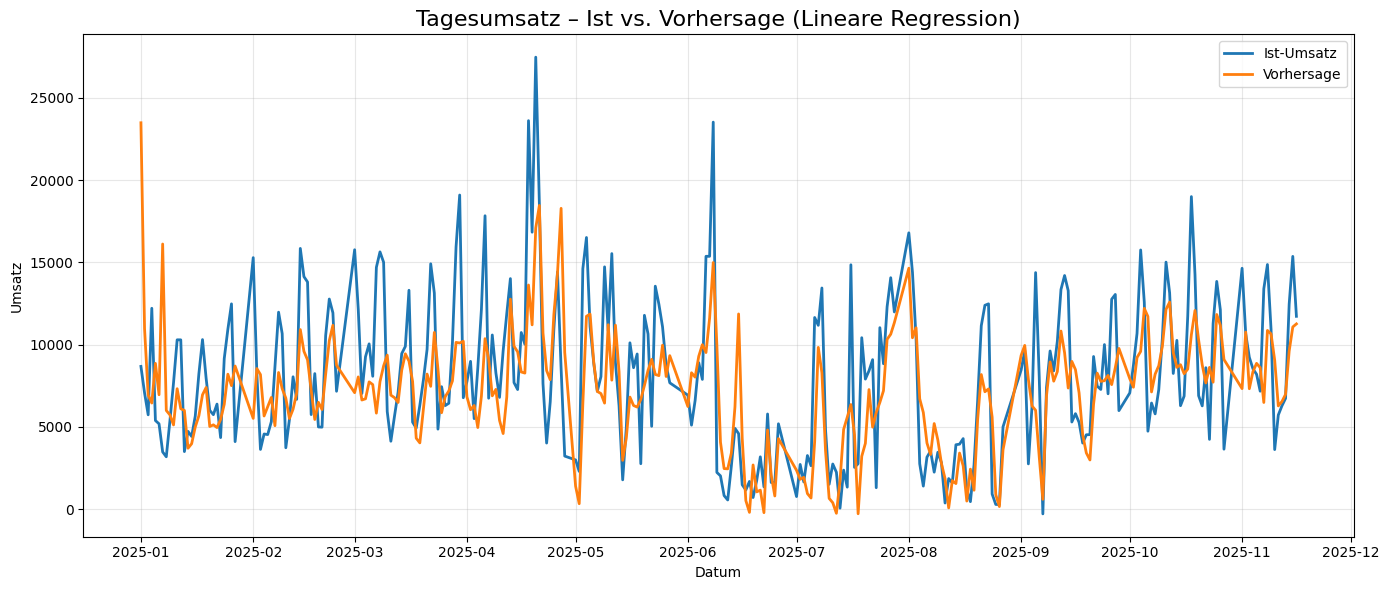

In [13]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 1) Daten laden
df = pd.read_csv("data/dataset-merged-2.csv")
# Datum konvertieren & sortieren
df["Datum"] = pd.to_datetime(df["Datum"])
df = df.sort_values("Datum")

# 2) Zielvariable definieren
target = "Restaurant"

# 3) Lag-Features
df["lag1"] = df[target].shift(1)
df["lag2"] = df[target].shift(2)
df["lag7"] = df[target].shift(7)
df["lag30"] = df[target].shift(30)

# Lags erzeugen NaN → entfernen
df = df.dropna().reset_index(drop=True)

# 4) Feature-Auswahl
num_cols = df.select_dtypes(include=["number"]).columns

feature_cols = [c for c in num_cols if c != target]

X = df[feature_cols]
y = df[target]

# 5) Zeitbasiertes Train/Test-Split
split_date = pd.Timestamp("2025-01-01")

train_mask = df["Datum"] < split_date
test_mask  = df["Datum"] >= split_date

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

# 6) Standardisierung
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7) Modell trainieren
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 8) Vorhersage & Evaluation
y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

# 9) Ergebnis-Tabelle
results = pd.DataFrame({
    "Datum": df.loc[test_mask, "Datum"],
    "Ist": y_test.values,
    "Vorhersage": y_pred
    })

display(results.head(15))


plt.figure(figsize=(14,6))
plt.plot(results["Datum"], results["Ist"], label="Ist-Umsatz", linewidth=2)
plt.plot(results["Datum"], results["Vorhersage"], label="Vorhersage", linewidth=2)

plt.title("Tagesumsatz – Ist vs. Vorhersage (Lineare Regression)", fontsize=16)
plt.xlabel("Datum")
plt.ylabel("Umsatz")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



Random Forest Model

ARIMA Model

Train length: 1438
Test length : 289


c:\Projects\DSF_Group_Project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Projects\DSF_Group_Project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Projects\DSF_Group_Project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             Restaurant   No. Observations:                 1438
Model:                 ARIMA(5, 1, 3)   Log Likelihood              -13755.944
Date:                Tue, 25 Nov 2025   AIC                          27529.889
Time:                        17:04:28   BIC                          27577.321
Sample:                             0   HQIC                         27547.597
                               - 1438                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.4640      0.037     39.539      0.000       1.391       1.537
ar.L2         -1.2206      0.053    -22.828      0.000      -1.325      -1.116
ar.L3          0.2712      0.054      5.043      0.0

c:\Projects\DSF_Group_Project\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Projects\DSF_Group_Project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Projects\DSF_Group_Project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


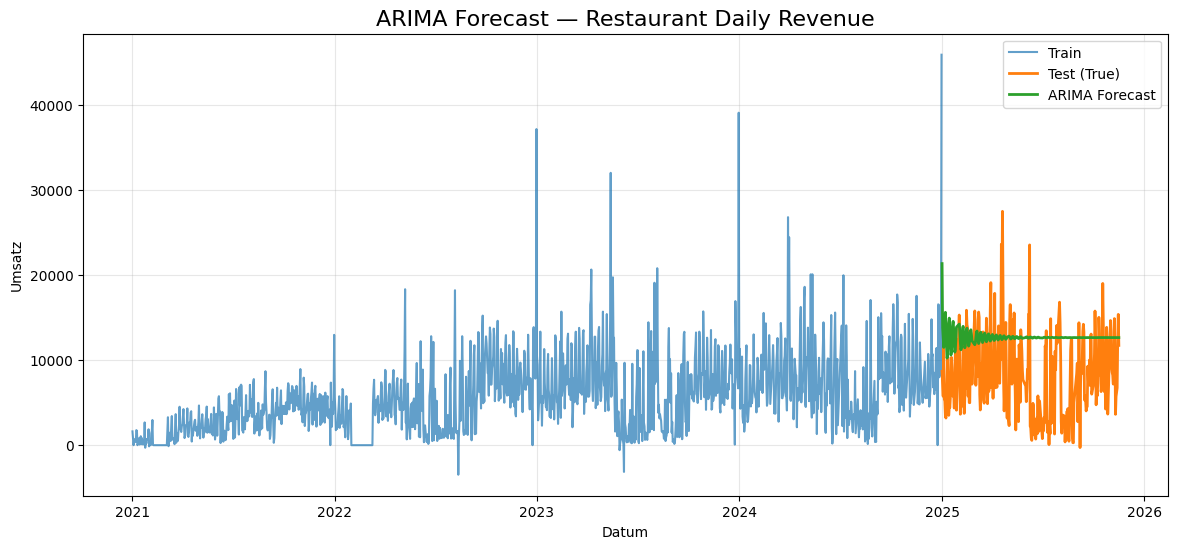

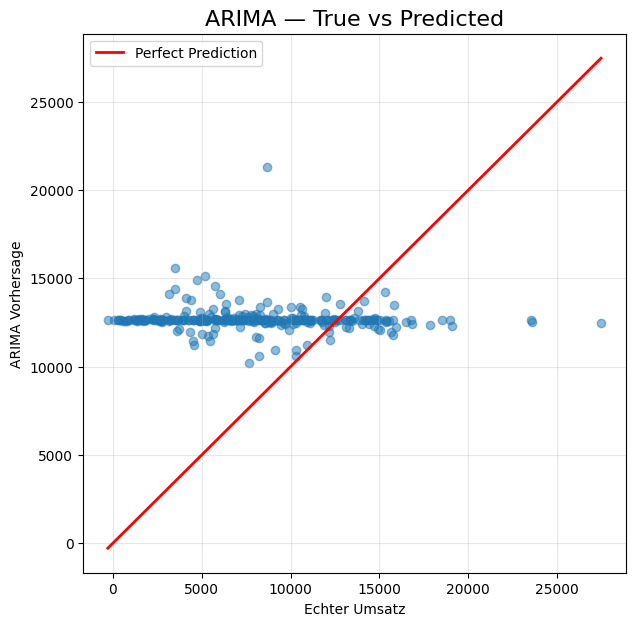

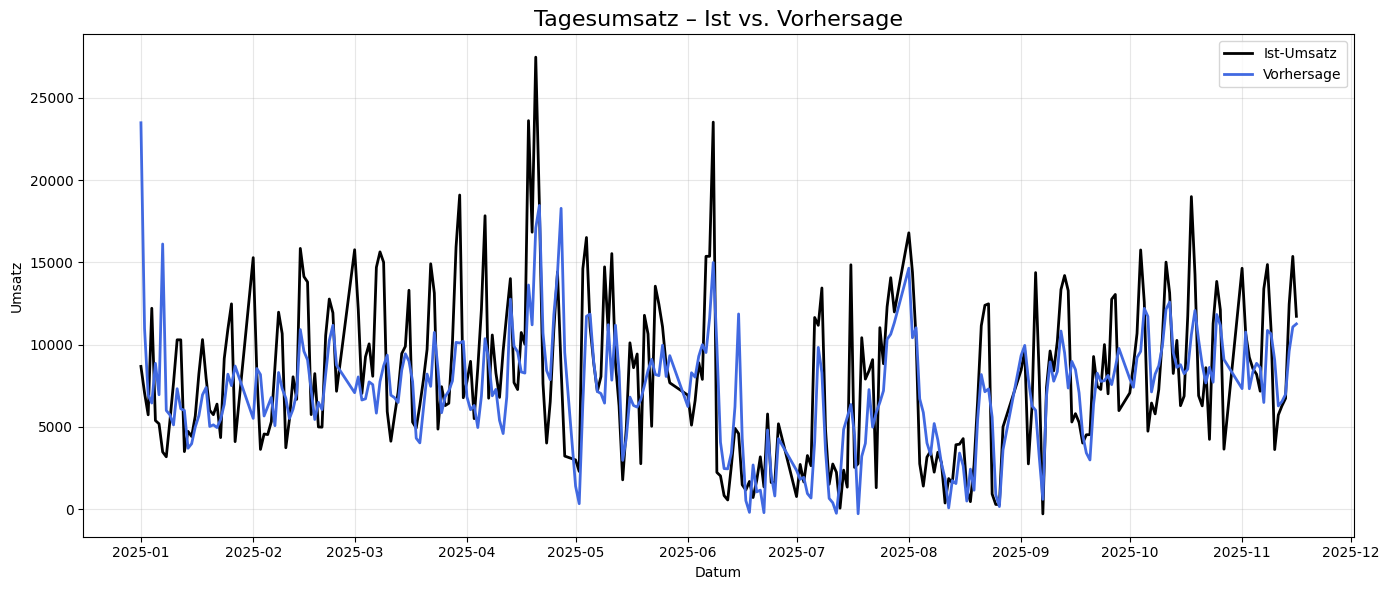

In [17]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, r2_score

# 1) Load dataset
df = pd.read_csv("data/dataset-merged-2.csv")
df["Datum"] = pd.to_datetime(df["Datum"])
df = df.sort_values("Datum")

# 2) Extract univariate time series for ARIMA
ts = df.set_index("Datum")["Restaurant"]

# 3) Train / Test Split (time-based)
split_date = pd.Timestamp("2025-01-01")

train = ts[ts.index < split_date]
test  = ts[ts.index >= split_date]

print("Train length:", len(train))
print("Test length :", len(test))

# 4) Fit ARIMA model
# Basic order (Auto-ARIMA would pick automatically, but we choose an initial set)
order = (5, 1, 3)   # You can tune this later

model = ARIMA(train, order=order)
model_fit = model.fit()

print(model_fit.summary())

# 5) Forecast over test period
forecast = model_fit.forecast(steps=len(test))

# 6) Evaluation
mse  = mean_squared_error(test, forecast)
rmse = mse ** 0.5
r2   = r2_score(test, forecast)

print(f"MSE : {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

# 7) Plot: Forecast vs True Values
plt.figure(figsize=(14,6))
plt.plot(train.index, train, label="Train", alpha=0.7)
plt.plot(test.index, test, label="Test (True)", linewidth=2)
plt.plot(test.index, forecast, label="ARIMA Forecast", linewidth=2)

plt.title("ARIMA Forecast — Restaurant Daily Revenue", fontsize=16)
plt.xlabel("Datum")
plt.ylabel("Umsatz")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 8) Scatter Plot: True vs Forecast
plt.figure(figsize=(7,7))
plt.scatter(test.values, forecast.values, alpha=0.5)
plt.plot([min(test), max(test)], [min(test), max(test)],
         color="red", linewidth=2, label="Perfect Prediction")

plt.title("ARIMA — True vs Predicted", fontsize=16)
plt.xlabel("Echter Umsatz")
plt.ylabel("ARIMA Vorhersage")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(14,6))

# Plot Ist (True values)
plt.plot(results["Datum"], results["Ist"], 
         label="Ist-Umsatz", 
         linewidth=2, 
         color="black")

# Plot Forecast
plt.plot(results["Datum"], results["Vorhersage"], 
         label="Vorhersage", 
         linewidth=2, 
         color="royalblue")

plt.title("Tagesumsatz – Ist vs. Vorhersage", fontsize=16)
plt.xlabel("Datum")
plt.ylabel("Umsatz")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

LSTM Model

Prophet Model